# 1. Intro

# Task 9: Industrial Predictive Maintenance

## Problem statement
A single machine failure can cost a factory millions. This project predicts machine failure types from operating sensors so maintenance can be planned before production is interrupted.

## Dataset
[AI4I 2020 Predictive Maintenance Dataset (UCI)](https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset). The local CSV contains product type, air temperature, process temperature, rotational speed, torque, tool wear, and failure-mode indicators.

## Objective
Classify each machine record as No failure or a specific failure type: Tool Wear Failure, Heat Dissipation Failure, Power Failure, Overstrain Failure, or Random Failure.

## Industry constraint
False Discovery Rate (FDR) is the primary metric. A false positive can halt production unnecessarily, so the final decision threshold is tuned to minimize false discoveries while retaining a minimum useful failure recall.

# 2. Imports & Setup

In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             mean_absolute_error, precision_score, recall_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

SEED = 42
DATA_PATH = Path('data/predictive_maintenance.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('task9-Industrial-Predictive-Maintenance/data/predictive_maintenance.csv')
ASSETS_DIR = Path('assets')
MODELS_DIR = Path('models')
ASSETS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)
np.random.seed(SEED)
pd.set_option('display.max_columns', 30)
print(f'Using dataset: {DATA_PATH.resolve()}')

Using dataset: D:\summerToTheFinal\elevvo\elevvo_projects\task9-Industrial-Predictive-Maintenance\data\predictive_maintenance.csv


# 3. Load & Explore Data

In [2]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head()

Shape: (10000, 12)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.info()
display(df.describe(include='all').T)
print('Missing values:')
display(df.isna().sum())
print('Machine failure distribution:')
display(df['Machine failure'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 10000 non-null  object 
 1   Air temperature      10000 non-null  float64
 2   Process temperature  10000 non-null  float64
 3   Rotational speed     10000 non-null  int64  
 4   Torque               10000 non-null  float64
 5   Tool wear            10000 non-null  int64  
 6   Machine failure      10000 non-null  int64  
 7   TWF                  10000 non-null  int64  
 8   HDF                  10000 non-null  int64  
 9   PWF                  10000 non-null  int64  
 10  OSF                  10000 non-null  int64  
 11  RNF                  10000 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 937.6+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Type,10000,3,L,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air temperature,10000.0,NaN,NaN,NaN,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature,10000.0,NaN,NaN,NaN,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed,10000.0,NaN,NaN,NaN,1538.7761,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque,10000.0,NaN,NaN,NaN,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear,10000.0,NaN,NaN,NaN,107.951,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,NaN,NaN,NaN,0.0339,0.180981,0.0,0.0,0.0,0.0,1.0
TWF,10000.0,NaN,NaN,NaN,0.0046,0.067671,0.0,0.0,0.0,0.0,1.0
HDF,10000.0,NaN,NaN,NaN,0.0115,0.106625,0.0,0.0,0.0,0.0,1.0
PWF,10000.0,NaN,NaN,NaN,0.0095,0.097009,0.0,0.0,0.0,0.0,1.0


Missing values:


Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0
Torque                 0
Tool wear              0
Machine failure        0
TWF                    0
HDF                    0
PWF                    0
OSF                    0
RNF                    0
dtype: int64

Machine failure distribution:


Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure type
No failure                  9652
Heat Dissipation Failure     115
Power Failure                 91
Overstrain Failure            78
Tool Wear Failure             46
Random Failure                18
Name: count, dtype: int64

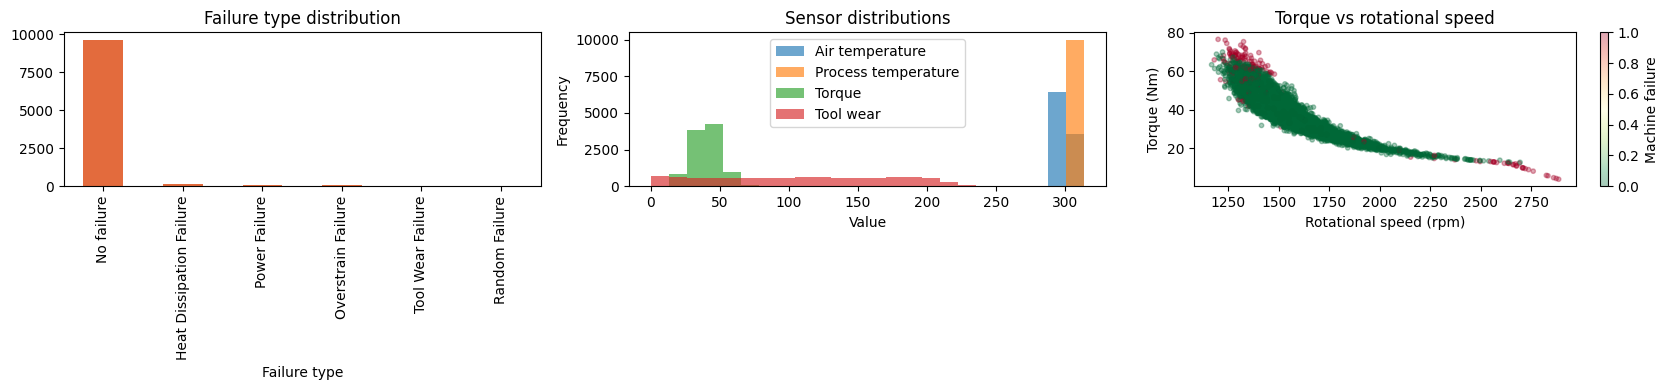

In [4]:
failure_flags = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_names = {
    'TWF': 'Tool Wear Failure',
    'HDF': 'Heat Dissipation Failure',
    'PWF': 'Power Failure',
    'OSF': 'Overstrain Failure',
    'RNF': 'Random Failure',
}
def first_failure_type(row):
    for flag in failure_flags:
        if row[flag] == 1:
            return failure_names[flag]
    return 'No failure'

df['Failure type'] = df.apply(first_failure_type, axis=1)
display(df['Failure type'].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
df['Failure type'].value_counts().plot.bar(ax=axes[0], color='#e36b3d', title='Failure type distribution')
df[['Air temperature', 'Process temperature', 'Torque', 'Tool wear']].plot.hist(alpha=0.65, bins=24, ax=axes[1], title='Sensor distributions')
axes[1].set_xlabel('Value')
scatter = axes[2].scatter(df['Rotational speed'], df['Torque'], c=df['Machine failure'], cmap='RdYlGn_r', alpha=0.35, s=10)
axes[2].set(title='Torque vs rotational speed', xlabel='Rotational speed (rpm)', ylabel='Torque (Nm)')
fig.colorbar(scatter, ax=axes[2], label='Machine failure')
plt.tight_layout()
plt.show()

# 4. Cleaning & Preprocessing

The failure flags and `Machine failure` are labels, not predictors, so they are excluded to prevent target leakage. Numeric sensor values receive median imputation, while the categorical product type receives most-frequent imputation and one-hot encoding. The encoder is fit only on the training data and saved for the live interface.

In [5]:
raw_feature_columns = ['Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear']
numeric_columns = ['Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear']
categorical_columns = ['Type']
X = df[raw_feature_columns].copy()
y = df['Failure type'].copy()

numeric_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median'))])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
encoder = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_columns),
    ('categorical', categorical_pipeline, categorical_columns),
], remainder='drop')

# 5. Feature Engineering

In [6]:
def engineer_features(frame):
    result = frame[raw_feature_columns].copy()
    result['Temperature difference'] = result['Process temperature'] - result['Air temperature']
    result['Thermal stress'] = result['Temperature difference'] * result['Tool wear']
    result['Torque-speed ratio'] = result['Torque'] / result['Rotational speed'].clip(lower=1)
    result['Power proxy'] = result['Torque'] * result['Rotational speed']
    return result

feature_columns = raw_feature_columns + ['Temperature difference', 'Thermal stress', 'Torque-speed ratio', 'Power proxy']
X_engineered = engineer_features(X)
numeric_columns = [column for column in feature_columns if column != 'Type']
X_engineered.head()

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Temperature difference,Thermal stress,Torque-speed ratio,Power proxy
0,M,298.1,308.6,1551,42.8,0,10.5,0.0,0.027595,66382.8
1,L,298.2,308.7,1408,46.3,3,10.5,31.5,0.032884,65190.4
2,L,298.1,308.5,1498,49.4,5,10.4,52.0,0.032977,74001.2
3,L,298.2,308.6,1433,39.5,7,10.4,72.8,0.027565,56603.5
4,L,298.2,308.7,1408,40.0,9,10.5,94.5,0.028409,56320.0


# 6. Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_engineered, y, test_size=0.20, stratify=y, random_state=SEED
)
X_fit, X_valid, y_fit, y_valid = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=SEED
)
print(X_fit.shape, X_valid.shape, X_test.shape)

(6000, 10) (2000, 10) (2000, 10)


# 7. Model Training

The baseline is balanced multinomial logistic regression. The final model is a balanced random forest, followed by a conservative decision rule. Rather than accepting every failure class with the highest probability, the threshold is selected on validation data to maximize precision among failure alerts while requiring at least 15% failure recall. The untouched test split is used only for final evaluation.

In [8]:
encoder.fit(X_fit)
X_fit_encoded = encoder.transform(X_fit)
X_valid_encoded = encoder.transform(X_valid)
X_test_encoded = encoder.transform(X_test)

baseline_model = LogisticRegression(max_iter=3000, class_weight='balanced', random_state=SEED)
baseline_model.fit(X_fit_encoded, y_fit)
baseline_predictions = baseline_model.predict(X_test_encoded)
print('Baseline macro F1:', round(f1_score(y_test, baseline_predictions, average='macro'), 4))

final_model = RandomForestClassifier(
    n_estimators=350, class_weight='balanced_subsample', min_samples_leaf=2,
    random_state=SEED, n_jobs=-1
)
final_model.fit(X_fit_encoded, y_fit)
class_names = list(final_model.classes_)
no_failure_index = class_names.index('No failure')
failure_indices = [index for index, name in enumerate(class_names) if name != 'No failure']
valid_probabilities = final_model.predict_proba(X_valid_encoded)
valid_failure_scores = valid_probabilities[:, failure_indices].max(axis=1)
valid_failure_classes = np.asarray(class_names)[np.asarray(failure_indices)[valid_probabilities[:, failure_indices].argmax(axis=1)]]

threshold_rows = []
valid_failure_truth = (y_valid.to_numpy() != 'No failure').astype(int)
for threshold in np.arange(0.10, 0.96, 0.01):
    predicted_failure = (valid_failure_scores >= threshold).astype(int)
    precision = precision_score(valid_failure_truth, predicted_failure, zero_division=0)
    recall = recall_score(valid_failure_truth, predicted_failure, zero_division=0)
    threshold_rows.append({'threshold': threshold, 'precision': precision, 'recall': recall, 'fdr': 1 - precision})
threshold_table = pd.DataFrame(threshold_rows)
eligible = threshold_table[threshold_table['recall'] >= 0.15]
chosen_threshold = float(eligible.sort_values(['fdr', 'threshold']).iloc[0]['threshold']) if not eligible.empty else 0.5
print('Chosen validation threshold:', chosen_threshold)

D:\summerToTheFinal\elevvo\elevvo_projects\task1-Student Score-Prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Baseline macro F1: 0.3548
Chosen validation threshold: 0.6199999999999998


# 8. Evaluation

False Discovery Rate is reported for the binary operational decision: any failure alert versus No failure. Failure-type precision, recall, and F1 are also reported for the multiclass predictions.

False Discovery Rate: 0.0000
Precision: 1.0000
Recall: 0.2857
Macro F1: 0.4217
                          precision    recall  f1-score   support

Heat Dissipation Failure       1.00      0.39      0.56        23
              No failure       0.97      1.00      0.99      1930
      Overstrain Failure       1.00      0.38      0.55        16
           Power Failure       1.00      0.28      0.43        18
          Random Failure       0.00      0.00      0.00         4
       Tool Wear Failure       0.00      0.00      0.00         9

                accuracy                           0.97      2000
               macro avg       0.66      0.34      0.42      2000
            weighted avg       0.97      0.97      0.97      2000



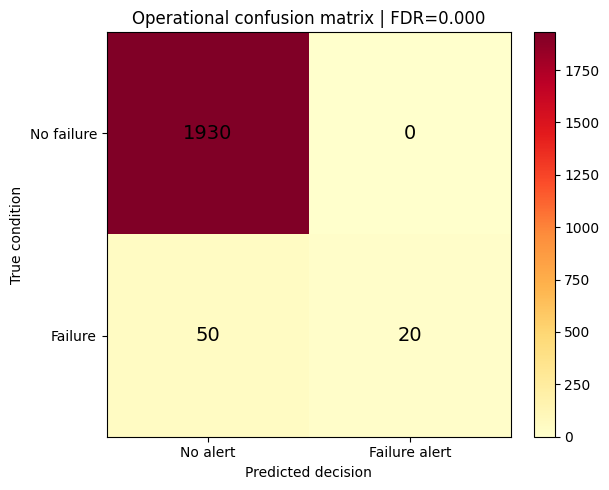

In [9]:
test_probabilities = final_model.predict_proba(X_test_encoded)
test_failure_scores = test_probabilities[:, failure_indices].max(axis=1)
test_failure_classes = np.asarray(class_names)[np.asarray(failure_indices)[test_probabilities[:, failure_indices].argmax(axis=1)]]
test_failure_alert = test_failure_scores >= chosen_threshold
test_labels = np.where(test_failure_alert, test_failure_classes, 'No failure')
true_failure = (y_test.to_numpy() != 'No failure').astype(int)
predicted_failure = test_failure_alert.astype(int)
precision = precision_score(true_failure, predicted_failure, zero_division=0)
recall = recall_score(true_failure, predicted_failure, zero_division=0)
fdr = 1 - precision
print(f'False Discovery Rate: {fdr:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print('Macro F1:', round(f1_score(y_test, test_labels, average='macro'), 4))
print(classification_report(y_test, test_labels, zero_division=0))

cm = confusion_matrix(true_failure, predicted_failure)
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(cm, cmap='YlOrRd')
ax.set_xticks([0, 1], ['No alert', 'Failure alert'])
ax.set_yticks([0, 1], ['No failure', 'Failure'])
ax.set_xlabel('Predicted decision')
ax.set_ylabel('True condition')
ax.set_title(f'Operational confusion matrix | FDR={fdr:.3f}')
for (row, column), value in np.ndenumerate(cm):
    ax.text(column, row, value, ha='center', va='center', fontsize=14)
fig.colorbar(image, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(ASSETS_DIR / 'results.png', dpi=160, bbox_inches='tight')
plt.show()

# 9. Bonus Work

### Time-to-Failure regression
The AI4I dataset does not include a measured remaining-useful-life label. Therefore, this section trains a transparent RUL proxy based on the remaining tool-wear budget, `max(0, 250 - Tool wear)`. It demonstrates the regression workflow but should not be treated as a validated maintenance-life estimate.

In [10]:
rul_features = X_engineered.drop(columns=['Type'])
rul_target = (250 - rul_features['Tool wear']).clip(lower=0)
rul_train, rul_test, rul_y_train, rul_y_test = train_test_split(
    rul_features, rul_target, test_size=0.20, random_state=SEED
)
rul_model = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
rul_model.fit(rul_train, rul_y_train)
rul_prediction = rul_model.predict(rul_test)
print('RUL proxy MAE:', round(mean_absolute_error(rul_y_test, rul_prediction), 3))

RUL proxy MAE: 0.002


### Sensor correlation / lead-indicator analysis

In [11]:
correlation_columns = ['Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Machine failure']
sensor_correlations = df[correlation_columns].corr()['Machine failure'].drop('Machine failure').sort_values(key=np.abs, ascending=False)
display(sensor_correlations.to_frame('correlation with machine failure'))
print('Lead indicator by absolute correlation:', sensor_correlations.index[0])

,correlation with machine failure
Torque,0.191321
Tool wear,0.105448
Air temperature,0.082556
Rotational speed,-0.044188
Process temperature,0.035946


Lead indicator by absolute correlation: Torque


# 10. Save Artifacts

In [12]:
metadata = {
    'feature_columns': feature_columns,
    'class_names': class_names,
    'decision_threshold': chosen_threshold,
    'fdr': float(fdr),
    'precision': float(precision),
    'recall': float(recall),
}
joblib.dump(final_model, MODELS_DIR / 'failure_model.joblib')
joblib.dump(encoder, MODELS_DIR / 'feature_encoder.joblib')
joblib.dump(metadata, MODELS_DIR / 'metadata.joblib')
joblib.dump(rul_model, MODELS_DIR / 'rul_model.joblib')
print('Saved:', sorted(path.name for path in MODELS_DIR.iterdir()))

Saved: ['failure_model.joblib', 'feature_encoder.joblib', 'metadata.joblib', 'rul_model.joblib']


# 11. Gradio Interface

The standalone `app.py` is intentionally the final interface layer. It loads the saved model, encoder, feature-name order, and decision threshold from `./models/`; it does not import or depend on this notebook. Run it locally with `python app.py`. The launch call uses `demo.launch(share=True)` so a screenshot can be captured during review.

In [13]:
# The executable interface lives in app.py and is kept last by design.
# From this task folder: python app.py